# Dados faltantes e estimação por máxima verossimilhança

---

## Motivação
Dados faltantes são onipresentes em aplicações estatísticas reais. A resposta mais simples (descartar as observações incompletas e trabalhar apenas com os casos completos) desperdiça informação e pode introduzir viés. Uma resposta mais elegante, devida a T. W. Anderson (1957), mostra que a estrutura da distribuição normal multivariada pode ser explorada para obter estimadores de máxima verossimilhança (máxima verossimilhança) de forma surpreendentemente simples, sem qualquer algoritmo iterativo.

A ideia central é a fatoração da verossimilhança: em vez de maximizar a log-verossimilhança conjunta de todos os parâmetros simultaneamente, podemos reescrevê-la como soma de duas partes que envolvem conjuntos distintos de parâmetros, permitindo maximização independente de cada parte.

Neste estudo dirigido vamos redescobrir essa ideia usando dados reais de qualidade do ar. O conjunto de dados airquality, contém $n = 153$ medições diárias em Nova York (maio–setembro de 1973). As duas variáveis de interesse são:

- $Y_1 = \text{Solar.R}$: radiação solar (em Langleys, 08h–12h, Aeroporto JFK);
- $Y_2 = \text{Ozone}$: concentração média de ozônio (partes por bilhão (ppb), 13h–15h, Roosevelt Island).

In [221]:
data(airquality)

head(airquality)

,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


---

## Análise Exploratória
Selecione as variáveis $\text{Solar.R}$ e $\text{Ozone}$ do dataset e classifique cada observação em um dos três padrões de dados faltantes: completo (ambas observadas), parcial ($Y_1$ observada, $Y_2$ faltante) e invertido ($Y_2$ observada, $Y_1$ faltante). Quantas observações há em cada padrão? O padrão é aproximadamente **monotônico**? Dizemos que um padrão é monotônico quando, para todo par de variáveis, qualquer observação com $Y_2$ faltante também tem $Y_1$ faltante – ou vice-versa.

Faça um gráfico de dispersão de $Y_2$ versus $Y_1$ para os casos completos e avalie visualmente a linearidade da relação. Experimente também o gráfico de $\ln(Y_2)$ versus $Y_1$. Qual transformação parece mais adequada para satisfazer a suposição de normalidade bivariada? Justifique com histogramas e/ou diagramas de nível bivariados.

Calcule a média amostral de $Y_1$ usando: (i) apenas os casos com $Y_1$ e $Y_2$ observados; (ii) todos os casos em que $Y_1$ está observada. As duas estimativas diferem? Qual tem menor erro padrão e por quê?

Por fim, suponha que a probabilidade de Y2 estar faltante depende apenas do valor observado de $Y_1$ (mecanismo Missing at Random, MAR). O que isso significa neste problema? Você acha plausível essa suposição para dados de ozônio e radiação solar? Por quê?

In [222]:
airquality$label <- ifelse(!is.na(airquality$Solar.R) & !is.na(airquality$Ozone), "complete",
                     ifelse(!is.na(airquality$Solar.R) & is.na(airquality$Ozone), "partial",
                     ifelse(is.na(airquality$Solar.R) & !is.na(airquality$Ozone), "inverted", "missing")))

table(airquality$label)


complete inverted  missing  partial 
     111        5        2       35 

como podemos ver na classificação, as amostras parciais são em maior número, então os dados são aproximadamente **monotônicos**, de forma que $Y_1$ é a variável mais completa

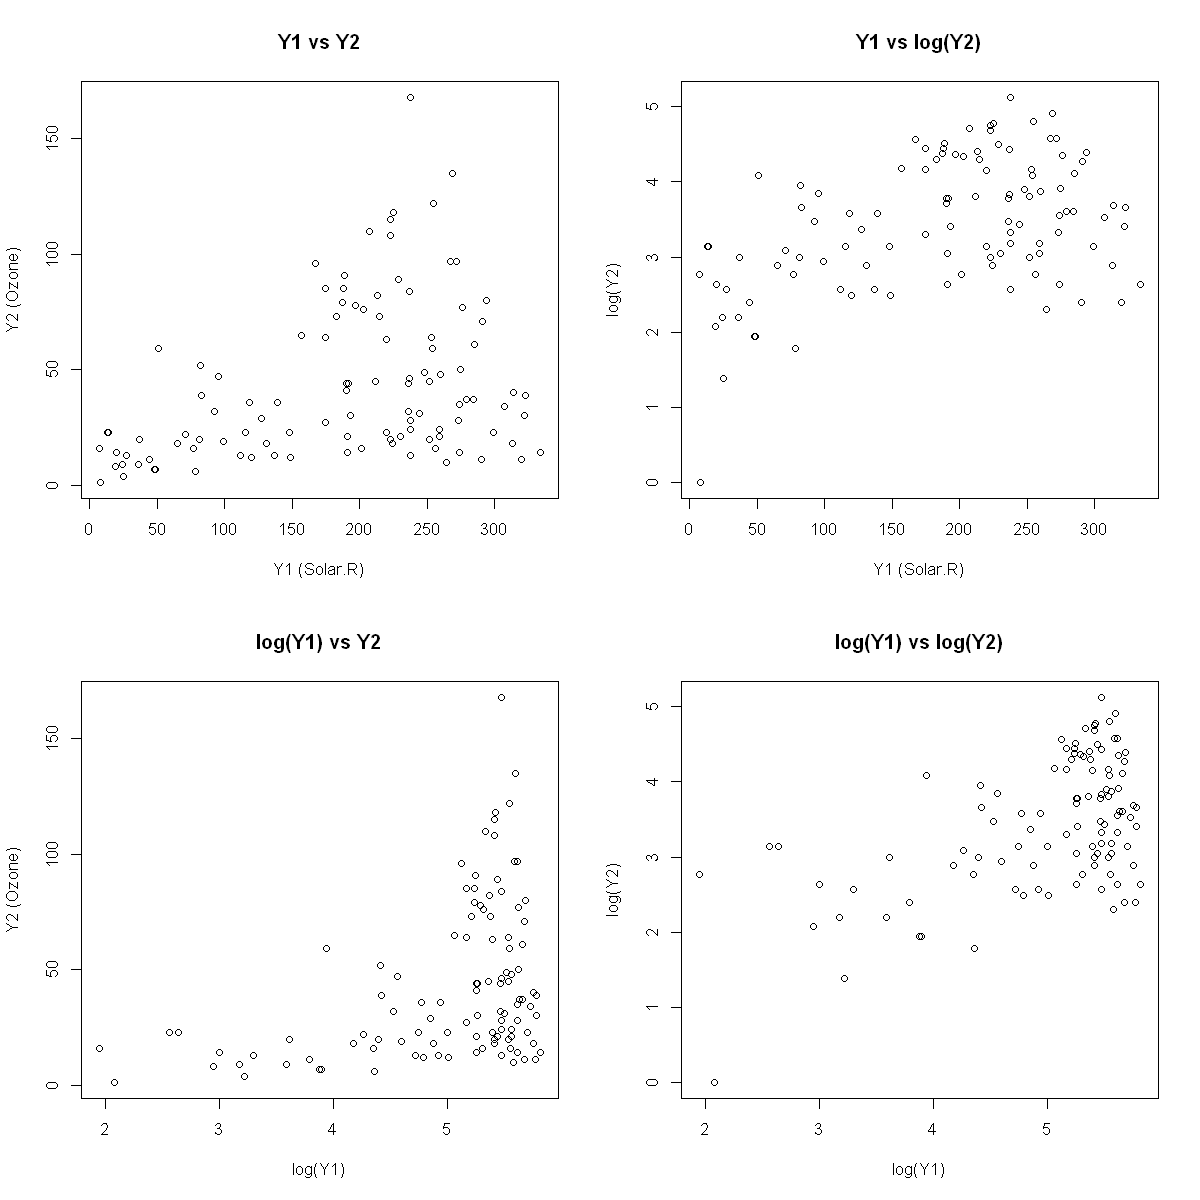

In [223]:
data(airquality)

options(repr.plot.width = 10, repr.plot.height = 10)
par(mfrow = c(2, 2), bg = "white")

plot(airquality$Solar.R, airquality$Ozone,
     xlab = "Y1 (Solar.R)", ylab = "Y2 (Ozone)", main = "Y1 vs Y2")

plot(airquality$Solar.R, log(airquality$Ozone),
     xlab = "Y1 (Solar.R)", ylab = "log(Y2)", main = "Y1 vs log(Y2)")

plot(log(airquality$Solar.R), airquality$Ozone,
     xlab = "log(Y1)", ylab = "Y2 (Ozone)", main = "log(Y1) vs Y2")

plot(log(airquality$Solar.R), log(airquality$Ozone),
     xlab = "log(Y1)", ylab = "log(Y2)", main = "log(Y1) vs log(Y2)")

par(mfrow = c(1, 1))  # volta pro layout normal depois

olhando os gráficos, não conseguimos afirmar com uma total certeza qual das transformações mais se parece com uma normal multivariada, então vamos aplicar outras visualizações

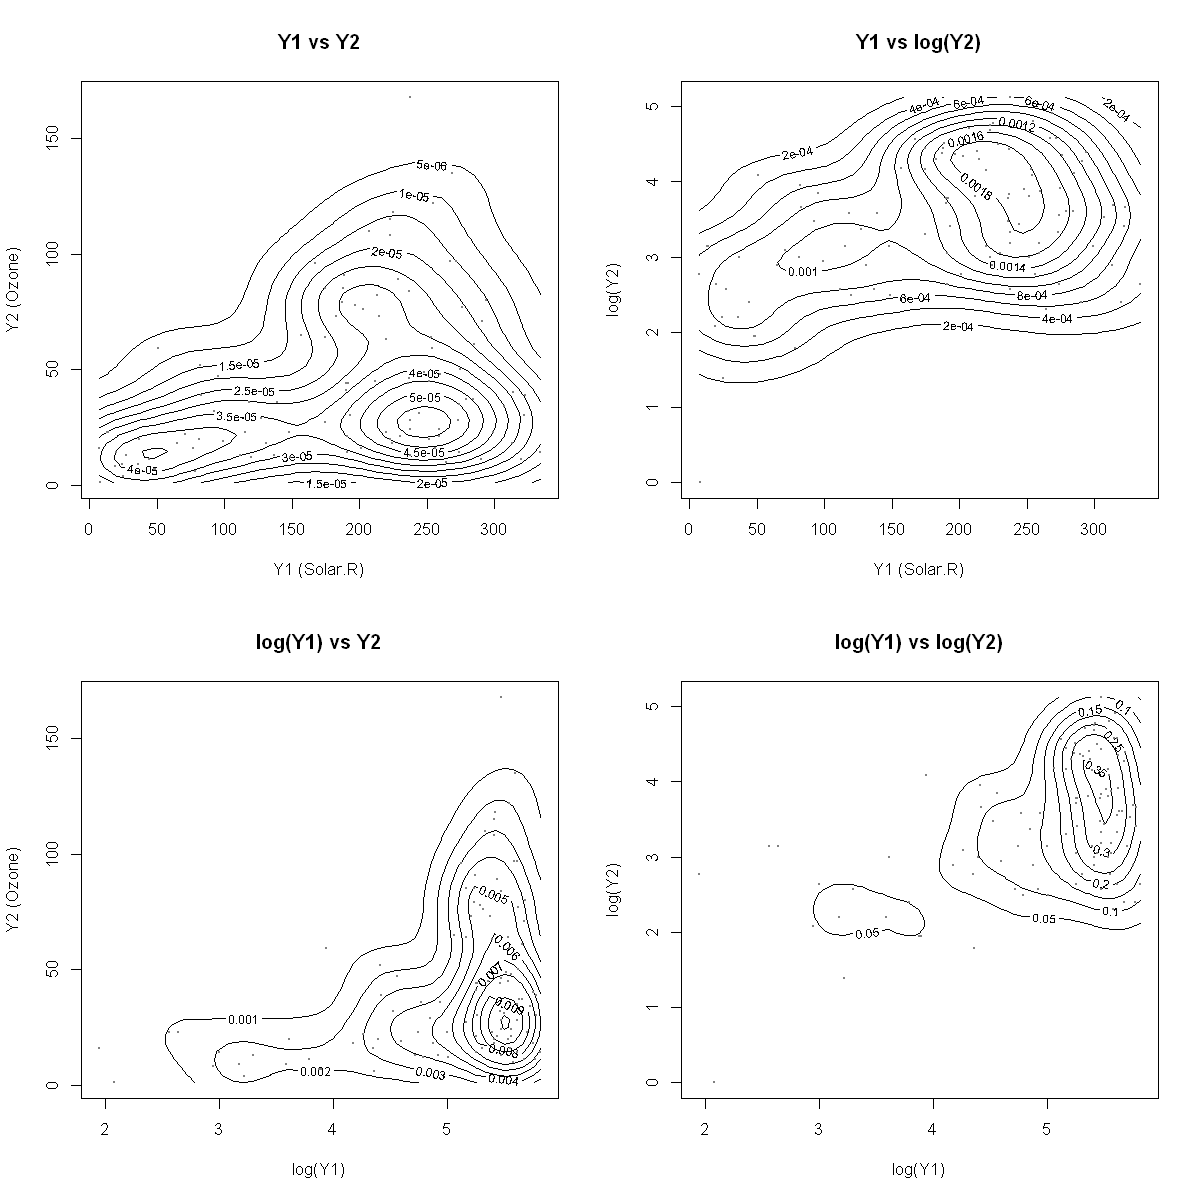

In [224]:
library(MASS)  # já vem com o R, não precisa instalar

data(airquality)
aq <- na.omit(airquality[, c("Solar.R", "Ozone")])  # diagrama de nível exige pares completos

par(mfrow = c(2, 2), bg = "white")

d1 <- kde2d(aq$Solar.R, aq$Ozone, n = 50)
contour(d1, xlab = "Y1 (Solar.R)", ylab = "Y2 (Ozone)", main = "Y1 vs Y2")
points(aq$Solar.R, aq$Ozone, pch = 20, cex = 0.5, col = "gray50")

d2 <- kde2d(aq$Solar.R, log(aq$Ozone), n = 50)
contour(d2, xlab = "Y1 (Solar.R)", ylab = "log(Y2)", main = "Y1 vs log(Y2)")
points(aq$Solar.R, log(aq$Ozone), pch = 20, cex = 0.5, col = "gray50")

d3 <- kde2d(log(aq$Solar.R), aq$Ozone, n = 50)
contour(d3, xlab = "log(Y1)", ylab = "Y2 (Ozone)", main = "log(Y1) vs Y2")
points(log(aq$Solar.R), aq$Ozone, pch = 20, cex = 0.5, col = "gray50")

d4 <- kde2d(log(aq$Solar.R), log(aq$Ozone), n = 50)
contour(d4, xlab = "log(Y1)", ylab = "log(Y2)", main = "log(Y1) vs log(Y2)")
points(log(aq$Solar.R), log(aq$Ozone), pch = 20, cex = 0.5, col = "gray50")

As visualizações ainda não são muito esclarecedoreas, elas dão indícios de que $Y_1$ e $\ln(Y_2)$ seguem uma normal multivariada, mas as outras também não estão tão distantes, então vamos tentar fazer um teste de hipótese e analisar as estatísticas de teste. Definimos então:
$$
    H_0: \text{Dados vem de uma normal multivariada}        \\
    H_1: \text{Dados não vem de uma normal multivariada}
$$
e vamos aplicar 3 testes em cada uma das transformações, o teste de Mardia, Royston e Henze-Zirkler

In [225]:
# Instalando o pacote de análise multivariada para o teste de normalidade

install.packages("MVN")

Warning message:
"o pacote 'MVN' está em uso e não será instalado"


In [226]:
library(MVN)
library(MASS)

In [227]:
aq <- na.omit(airquality[, c("Solar.R", "Ozone")])  # diagrama de nível exige pares completos

transformacoes <- list(
  "original" = aq,
  "log_y2"   = data.frame(Solar.R = aq$Solar.R, log_Ozone = log(aq$Ozone)),
  "log_y1"   = data.frame(log_Solar.R = log(aq$Solar.R), Ozone = aq$Ozone),
  "log_both" = data.frame(log_Solar.R = log(aq$Solar.R), log_Ozone = log(aq$Ozone))
)

resultados_mvn <- list()

for (nome in names(transformacoes)) {
  resultados_mvn[[nome]] <- list(
    mardia  = mvn(data = transformacoes[[nome]], mvn_test = "mardia")$multivariate_normality,
    hz      = mvn(data = transformacoes[[nome]], mvn_test = "hz")$multivariate_normality,
    royston = mvn(data = transformacoes[[nome]], mvn_test = "royston")$multivariate_normality
  )
}

In [228]:
ver_testes <- function(nome_transformacao) {
  if (!nome_transformacao %in% names(resultados_mvn)) {
    stop("Transformação não encontrada! Escolha entre: 'original', 'log_y2', 'log_y1' ou 'log_both'.")
  }
  
  cat("=========================================================\n")
  cat(" RESULTADOS DE NORMALIDADE MULTIVARIADA PARA:", toupper(nome_transformacao), "\n")
  cat("=========================================================\n\n")
  
  cat("--- Teste de Mardia (Skewness e Kurtosis) ---\n")
  print(resultados_mvn[[nome_transformacao]]$mardia)
  cat("\n---------------------------------------------------------\n")
  
  cat("--- Teste de Henze-Zirkler (HZ) ---\n")
  print(resultados_mvn[[nome_transformacao]]$hz)
  cat("\n---------------------------------------------------------\n")
  
  cat("--- Teste de Royston ---\n")
  print(resultados_mvn[[nome_transformacao]]$royston)
}

In [229]:
ver_testes("original")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: ORIGINAL 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    45.288  <0.001 asymptotic ✗ Not normal
2 Mardia Kurtosis    -0.573   0.567 asymptotic     ✓ Normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler     4.063  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston    48.389  <0.001 asymptotic ✗ Not normal


In [230]:
ver_testes("log_y1")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: LOG_Y1 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    86.315  <0.001 asymptotic ✗ Not normal
2 Mardia Kurtosis     3.092   0.002 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler     6.021  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston    76.684  <0.001 asymptotic ✗ Not normal


In [231]:
ver_testes("log_y2")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: LOG_Y2 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    15.355   0.004 asymptotic ✗ Not normal
2 Mardia Kurtosis    -0.509   0.611 asymptotic     ✓ Normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler     2.363  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston     24.18  <0.001 asymptotic ✗ Not normal


In [232]:
ver_testes("log_both")

 RESULTADOS DE NORMALIDADE MULTIVARIADA PARA: LOG_BOTH 

--- Teste de Mardia (Skewness e Kurtosis) ---
             Test Statistic p.value     Method          MVN
1 Mardia Skewness    52.994  <0.001 asymptotic ✗ Not normal
2 Mardia Kurtosis     3.459  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Henze-Zirkler (HZ) ---
           Test Statistic p.value     Method          MVN
1 Henze-Zirkler      4.51  <0.001 asymptotic ✗ Not normal

---------------------------------------------------------
--- Teste de Royston ---
     Test Statistic p.value     Method          MVN
1 Royston    52.522  <0.001 asymptotic ✗ Not normal


Os únicos testes que encontraram alguma evidência de normalidade foram os testes mardia de kurtosis no dataset original e no com $Y_2$ transformado. Então podemos partir para uma abordagem mais visual usando os gráficos que vimos antes para escolher um para aplicar a hipótese de normalidade! Em minha opinião, o gráfico com $Y_2$ transformado é mais interessante, pois ele mostra uma melhor concentração dos pontos, enquanto no original os dados parecem vir de uma distribuição com duas médias distintas

In [233]:
# Calculando a média das amostras
data <- data.frame(Solar.R = airquality$Solar.R, log_Ozone = log(airquality$Ozone))
completos <- !is.na(data$Solar.R) & !is.na(data$log_Ozone)
y1_c <- data$Solar.R[completos]

n_c    <- length(y1_c)
media_c <- mean(y1_c)
dp_c   <- sd(y1_c)
ep_c   <- dp_c / sqrt(n_c)

y1_t <- data$Solar.R[!is.na(data$Solar.R)]

n_t    <- length(y1_t)
media_t <- mean(y1_t)
dp_t   <- sd(y1_t)
ep_t   <- dp_t / sqrt(n_t)

data.frame(
  grupo = c("completo", "todos"),
  n = c(n_c, n_t),
  media = c(media_c, media_t),
  desvio_padrao = c(dp_c, dp_t),
  erro_padrao = c(ep_c, ep_t)
)

grupo,n,media,desvio_padrao,erro_padrao
<chr>,<int>,<dbl>,<dbl>,<dbl>
completo,111,184.8018,91.15230,8.651794
todos,146,185.9315,90.05842,7.453288


de acordo com as estatísticas, o erro padrão da estimativa com todas as amostras é bem menor, o que é bem plausível, dado a distribuição da estatística da média:
$$
    \bar{Y}1 \sim N\left(\mu{Y_1}, \frac{\sigma_{Y_1}^2}{n}\right)
$$
ou seja, quanto maior o número de amostras, menor é o erro padrão da minha estimativa

In [234]:
head(airquality)

,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


Com relação à premissa do MARS, resumindo-a matematicamente:
$$
    \mathbb{P}(\text{faltante}(Y_2)|Y_1,Y_2) = \mathbb{P}(\text{faltante}(Y_2)|Y_1)
$$
Em nosso contexto, eu prefiro argumentar que a premissa **MAR** é plausível, pois dias com radiação solar muito baixa costumam coincidir com condições climáticas adversas (nebulosidade densa, tempestades), e esse tipo de clima pode afetar a operação de equipamentos de monitoramento de forma mais ampla — não é implausível que falhas no sensor de ozônio fossem mais comuns nesses dias, criando uma correlação entre `Solar.R` baixo e `Ozone` faltante

---
## O estimador de casos completos
Seja $r$ o número de casos completos (com $Y_1$ e $Y_2$ ambos observados) e $n$ o total de observações com $Y_1$ observada. Usando apenas os $r$ casos completos, estime os cinco parâmetros da distribuição normal bivariada: $\hat{\mu}_1^{CC}$, $\hat{\mu}_2^{CC}$, $\hat{\sigma}_{11}^{CC}$, $\hat{\sigma}_{22}^{CC}$, $\hat{\sigma}_{12}^{CC}$. Use as fórmulas amostrais de máxima verossimilhança (divisão por r).

Mostre numericamente que o estimador de $\mu_1$ usando todos os $n$ casos tem erro padrão menor do que aquele baseado apenas nos $r$ casos completos. Qual é a razão $\sqrt{r/n}$ nos seus dados?

Sob MAR, o estimador CC para $\mu_2$ é não viesado? Apresente um argumento intuitivo e verifique empiricamente via simulação: gere 1.000 amostras de uma normal bivariada com os parâmetros estimados, aplique o mecanismo MAR artificialmente e compare as médias dos estimadores CC e do verdadeiro $\mu_2$. Construa um intervalo de confiança de $95$% para $\mu_2$ usando o estimador CC

In [235]:
airquality$logOzone <- log(airquality$Ozone)

completos <- !is.na(airquality$Solar.R) & !is.na(airquality$logOzone)
y1 <- airquality$Solar.R[completos]
y2 <- airquality$logOzone[completos]
n  <- length(y1)

mu1_cc <- mean(y1)
mu2_cc <- mean(y2)

sigma11_cc <- sqrt(sum((y1 - mu1_cc)^2) / n)
sigma22_cc <- sqrt(sum((y2 - mu2_cc)^2) / n)
sigma12_cc <- sum((y1 - mu1_cc) * (y2 - mu2_cc)) / n

# Resultado organizado
data.frame(
  parametro  = c("mu1_CC", "mu2_CC", "sigma11_CC", "sigma22_CC", "sigma12_CC"),
  estimativa = c(mu1_cc, mu2_cc, sigma11_cc, sigma22_cc, sigma12_cc)
)

parametro,estimativa
<chr>,<dbl>
mu1_CC,184.8018018
mu2_CC,3.4159273
sigma11_CC,90.7407772
sigma22_CC,0.8619586
sigma12_CC,35.6744082


mostrando o erro das estimativas da média usando os dois grupos (completo e todas as amostras)

In [236]:
# Calculando a média das amostras
data <- data.frame(Solar.R = airquality$Solar.R, log_Ozone = log(airquality$Ozone))
completos <- !is.na(data$Solar.R) & !is.na(data$log_Ozone)
y1_c <- data$Solar.R[completos]

n_c    <- length(y1_c)
media_c <- mean(y1_c)
dp_c   <- sd(y1_c)
ep_c   <- dp_c / sqrt(n_c)

y1_t <- data$Solar.R[!is.na(data$Solar.R)]

n_t    <- length(y1_t)
media_t <- mean(y1_t)
dp_t   <- sd(y1_t)
ep_t   <- dp_t / sqrt(n_t)

data.frame(
  grupo = c("completo", "todos"),
  n = c(n_c, n_t),
  media = c(media_c, media_t),
  desvio_padrao = c(dp_c, dp_t),
  erro_padrao = c(ep_c, ep_t)
)

grupo,n,media,desvio_padrao,erro_padrao
<chr>,<int>,<dbl>,<dbl>,<dbl>
completo,111,184.8018,91.15230,8.651794
todos,146,185.9315,90.05842,7.453288


como ja comentado anteriormente, por conta do erro padrão da distribuição da média depender inversamente da quantidade de dados, o resultado será menor quanto maior a quantidade de dados. Calculando razão $\sqrt{r/n}$

In [237]:
n_completos <- sum(!is.na(airquality$Solar.R) & !is.na(airquality$Ozone))
n_y1_observado <- sum(!is.na(airquality$Solar.R))

data.frame(
  categoria = c("completos", "y1_observado"),
  n = c(n_completos, n_y1_observado),
  sqrt_proporcao = c(sqrt(n_completos / nrow(airquality)), sqrt(n_y1_observado / nrow(airquality)))
)

categoria,n,sqrt_proporcao
<chr>,<int>,<dbl>
completos,111,0.8517571
y1_observado,146,0.9768564


mas será que, sob o MAR, o estimador de $\mu_2$ é viezado? Intuitivamente, podemos pensar que sim, já que, como o valor de $Y_2$ ser observado ou não depende do valor de $Y_1$, a média estimada não é necessariamente a média verdadeira de $Y_2$, pois como estamos observando apenas os valores em que **ambos** foram observados, eu não consigo olhar a distribuição de $Y_2$ marginalmente sem a influência da permissão de observabilidade imposta por $Y_1$

agora vou fazer a simulação com outras normais multivariadas

                                      estatistica            valor
                                   mu2 verdadeiro           3.4159
            media estimada (simulacao, 1000 reps)           3.5434
               vies estimado (media - verdadeiro)          0.12752
 DP da media nos dados reais (erro padrao, n=111)         0.082185
                  DP dos estimadores na simulacao         0.078905
                     IC medio das 1000 simulacoes (3.3841, 3.7028)
                     estatistica t (H0: vies = 0)           51.107
                           p-valor (H0: vies = 0)      5.3253e-281


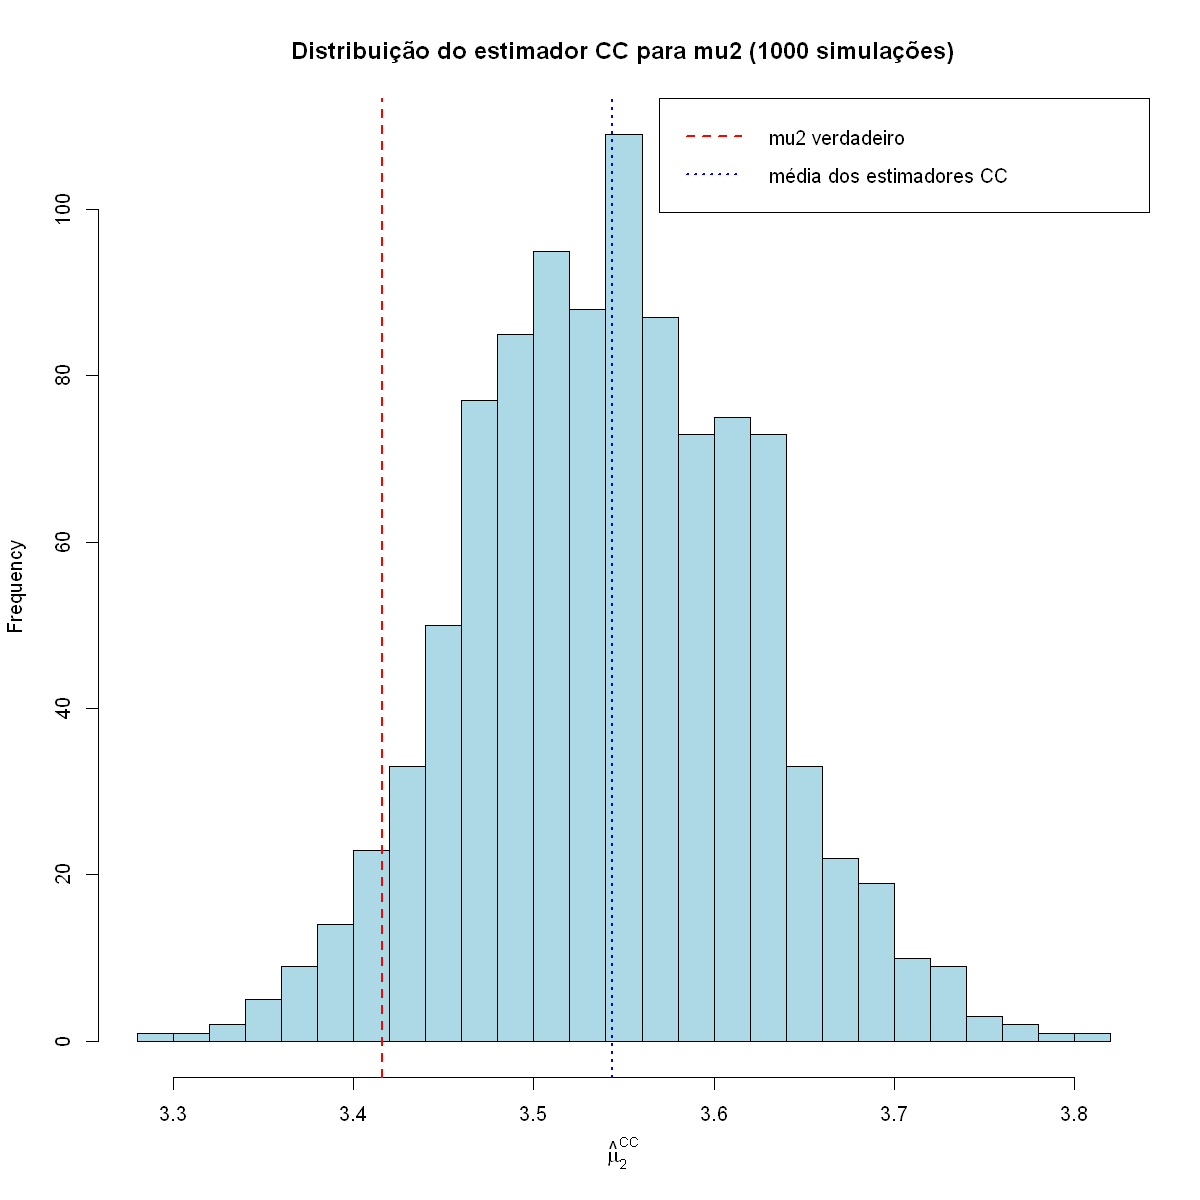

In [238]:
# Parâmetros "verdadeiros" da simulação = as estimativas CC já calculadas
mu_verdadeiro    <- c(mu1_cc, mu2_cc)
sigma11_cc       <- sigma11_cc^2   # correção: voltar de DP pra variância
sigma22_cc       <- sigma22_cc^2
Sigma_verdadeira <- matrix(c(sigma11_cc, sigma12_cc,
                             sigma12_cc, sigma22_cc), nrow = 2) + 1e-6 * diag(2)

set.seed(42)
n_sim <- 1000
N     <- 153

estimativas_cc <- numeric(n_sim)
ic_inf         <- numeric(n_sim)
ic_sup         <- numeric(n_sim)

for (i in 1:n_sim) {
  dados_sim <- mvrnorm(N, mu = mu_verdadeiro, Sigma = Sigma_verdadeira)

  y1_sim <- dados_sim[, 1]
  y2_sim <- dados_sim[, 2]

  z <- (y1_sim - mu_verdadeiro[1]) / sqrt(Sigma_verdadeira[1, 1])

  # Quanto maior y1, menor a chance de faltar y2 (MAR)
  p_faltante <- plogis(-1.15 - 1.5 * z)
  faltante_sim <- rbinom(N, size = 1, prob = p_faltante) == 1

  y2_cc_sim <- y2_sim[!faltante_sim]
  n_cc_sim  <- length(y2_cc_sim)

  media_cc_sim <- mean(y2_cc_sim)
  ep_cc_sim    <- sd(y2_cc_sim) / sqrt(n_cc_sim)

  estimativas_cc[i] <- media_cc_sim
  ic_inf[i] <- media_cc_sim - 1.96 * ep_cc_sim
  ic_sup[i] <- media_cc_sim + 1.96 * ep_cc_sim
}

# Teste de hipótese: H0: viés = 0
teste_vies <- t.test(estimativas_cc, mu = mu_verdadeiro[2])

# Erro padrão da média nos dados reais (n = 111, casos completos reais)
completos  <- !is.na(airquality$Solar.R) & !is.na(airquality$logOzone)
y2_real_cc <- airquality$logOzone[completos]
n_real_cc  <- length(y2_real_cc)
ep_real    <- sd(y2_real_cc) / sqrt(n_real_cc)

# Intervalo médio obtido nas simulações
ic_medio <- paste0(
  "(",
  signif(mean(ic_inf), 5),
  ", ",
  signif(mean(ic_sup), 5),
  ")"
)

# Resumo organizado
resumo <- data.frame(
  estatistica = c(
    "mu2 verdadeiro",
    "media estimada (simulacao, 1000 reps)",
    "vies estimado (media - verdadeiro)",
    "DP da media nos dados reais (erro padrao, n=111)",
    "DP dos estimadores na simulacao",
    "IC medio das 1000 simulacoes",
    "estatistica t (H0: vies = 0)",
    "p-valor (H0: vies = 0)"
  ),
  valor = c(
    signif(mu_verdadeiro[2], 5),
    signif(mean(estimativas_cc), 5),
    signif(mean(estimativas_cc) - mu_verdadeiro[2], 5),
    signif(ep_real, 5),
    signif(sd(estimativas_cc), 5),
    ic_medio,
    signif(unname(teste_vies$statistic), 5),
    signif(teste_vies$p.value, 5)
  )
)

print(resumo, row.names = FALSE)

# Visualização
par(bg = "white")
hist(
  estimativas_cc,
  breaks = 30,
  col = "lightblue",
  main = "Distribuição do estimador CC para mu2 (1000 simulações)",
  xlab = expression(hat(mu)[2]^{CC})
)

abline(v = mu_verdadeiro[2], col = "red", lwd = 2, lty = 2)
abline(v = mean(estimativas_cc), col = "blue", lwd = 2, lty = 3)

legend(
  "topright",
  legend = c("mu2 verdadeiro", "média dos estimadores CC"),
  col = c("red", "blue"),
  lty = c(2, 3),
  lwd = 2
)

como podemos ver, o p-valor é **muito** abaixo de $0.05$, o que objetivamente nos leva a rejeitar a hipótese ($H_0$) de que o viés seja $0$